# Objetivo del Notebook:

# Llevar a cabo la creación de tres modelos de clasificación (Naive Bayes, Árbol de Decisión, KNN) para la identificación del tipo de negocio al cual pertenece una personalidad de acuerdo con sus variables socioeconómicas (Age, Female, Years, Certificates, Feedback, Salary).

# Posteriormente, se busca ver qué modelo es mejor clasificando binariamente por medio de sus métricas de evaluación. Esto para luego generar clústeres / segregaciones en base a correlaciones entre variables.

# Se busca generar 2 casos hipotéticos que no existen inicialmente en el dataset para ver en que agrupación se encontrarían y la probabilidad de ser eso cierto o no.

# Y encontrar otros conocimientos al realizar un análisis con lupa en múltiples variables que comprenden este dataset

# Descripción del dataset

# 'Sales_Rep' = 'ID' del asesor
# 'Business' = El departamento al que pertenece
# 'Age' = Edad del asesor
# 'Female' = Variable binaria que indica género femenino cuando es 1
# 'Years' = Años desde que entró a la empresa
# 'College' = Variable categórica ordinal que indica si el asesor tiene un diploma de universitario
# 'Personality' = Variable categórica nominal que indica la personalidad del asesor
# 'Certficates' = Número de diplomas / certificados que posee el asesor
# 'Feedback' = Escala de 1 a 4 que indica la retroalimentación del asesor para la empresa, siendo 1 la más baja y 4 la más alta
# 'Salary' = Salario anual del asesor en USD
# 'NPS' = Employee Net Promoter Score. Mide la lealtad, el compromiso y la satisfacción general del personal hacia su empresa
# 'Business_Num' = Variable binaria que índica departamento de Software cuando es 1

# Descripción

# 0.1 - Importamos todas las librerias necesarias

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz
from pydotplus import graph_from_dot_data
from IPython.display import Image
from six import StringIO
import pydotplus
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
import plotly.express as px, plotly.graph_objects as go
import seaborn as sns

# 0.2 - Importamos la base de datos y sus hojas

In [ ]:
drive.mount('/content/drive')
TechSalesReps = pd.read_excel ('/content/drive/MyDrive/Colab Notebooks/Analítica de Datos/Datasets/DBTechSales.xlsx')
TechSalesReps2 = pd.read_excel ('/content/drive/MyDrive/Colab Notebooks/Analítica de Datos/Datasets/DBTechSales.xlsx', sheet_name = 1) # Se puede colocar el 'número' de la hoja (recordando que la 2 sería la 1).
TechSalesReps, TechSalesReps2

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


(       Sales_Rep  Business  Age  Female  Years College Personality  \
 0              1  Hardware   59       1      2     Yes    Diplomat   
 1              2  Hardware   52       0     10     Yes    Diplomat   
 2              3  Software   47       1      1     Yes    Explorer   
 3              4  Hardware   61       0      2     Yes    Diplomat   
 4              5  Software   39       0      1      No    Diplomat   
 ...          ...       ...  ...     ...    ...     ...         ...   
 21985      21986  Software   44       0      1     Yes    Diplomat   
 21986      21987  Software   23       1      6     Yes     Analyst   
 21987      21988  Hardware   48       1      4     Yes    Sentinel   
 21988      21989  Software   29       0      4     Yes     Analyst   
 21989      21990  Software   23       1      2     Yes    Explorer   
 
        Certficates  Feedback  Salary  NPS  Business_Num  
 0                1      2.01   70200    5             0  
 1                4      3.6

# 0.3 - Organizamos los datos (Business(Hardware = 0 | Software = 1))

In [ ]:
TechSalesReps[['Business']] = TechSalesReps[['Business']].replace({'Hardware':0, 'Software':1}).astype(int)
TechSalesReps

/tmp/ipykernel_7666/2627802198.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  TechSalesReps[['Business']] = TechSalesReps[['Business']].replace({'Hardware':0, 'Software':1}).astype(int)


,Sales_Rep,Business,Age,Female,Years,College,Personality,Certficates,Feedback,Salary,NPS,Business_Num
0,1,0,59,1,2,Yes,Diplomat,1,2.01,70200,5,0
1,2,0,52,0,10,Yes,Diplomat,4,3.64,133000,10,0
2,3,1,47,1,1,Yes,Explorer,1,3.88,52600,8,1
3,4,0,61,0,2,Yes,Diplomat,3,2.70,96000,6,0
4,5,1,39,0,1,No,Diplomat,5,3.44,122000,7,1
...,...,...,...,...,...,...,...,...,...,...,...,...
21985,21986,1,44,0,1,Yes,Diplomat,4,1.80,128000,7,1
21986,21987,1,23,1,6,Yes,Analyst,6,1.77,53400,8,1
21987,21988,0,48,1,4,Yes,Sentinel,0,2.46,50400,4,0
21988,21989,1,29,0,4,Yes,Analyst,2,3.68,70000,10,1


# 0.4 - Definimos las variables independientes y dependiente

### Variables independientes para Techsales_Reps

In [ ]:
XD = TechSalesReps[['Age', 'Female', 'Years', 'Certficates', 'Feedback', 'Salary']]
XD

,Age,Female,Years,Certficates,Feedback,Salary
0,59,1,2,1,2.01,70200
1,52,0,10,4,3.64,133000
2,47,1,1,1,3.88,52600
3,61,0,2,3,2.70,96000
4,39,0,1,5,3.44,122000
...,...,...,...,...,...,...
21985,44,0,1,4,1.80,128000
21986,23,1,6,6,1.77,53400
21987,48,1,4,0,2.46,50400
21988,29,0,4,2,3.68,70000


### Variables independientes para Techsales_Reps_2 (Contienen información diferente)

In [ ]:
# Creamos las variables independientes para la segunda hoja:
XD2 = TechSalesReps2[['Age', 'Female', 'Years', 'Certficates', 'Feedback', 'Salary']]
XD2

,Age,Female,Years,Certficates,Feedback,Salary
0,50,0,1,1,3.52,43000
1,52,1,2,5,3.91,95600
2,54,1,9,3,2.04,78200
3,62,1,1,1,1.54,52600
4,43,1,2,2,1.67,67400
...,...,...,...,...,...,...
95,22,0,5,2,3.43,43000
96,38,1,9,1,3.02,46400
97,56,0,2,5,3.88,99000
98,45,0,1,2,3.78,89000


### Variable dependientes para Techsales_Reps

In [ ]:
yd = TechSalesReps[['Business']]
yd

,Business
0,0
1,0
2,1
3,0
4,1
...,...
21985,1
21986,1
21987,0
21988,1


# 1 - Implementamos el modelo Naive Bayes

# 1.2 -  Almacenamos el modelo, lo entrenamos y predecimos con las variables independientes y dependientes (XD, yd)

In [ ]:
XDArray = np.array(XD, dtype=float)
ydArray = np.array(yd, dtype=float)
# Entrenamos el Modelo (Fase Train). Creamos la variable 'modeloNB'.

modeloNB = GaussianNB() # Variable que aloja el modelo.

# Ahora alimentaremos al modelo con las variables necesarias para que el modelo sea entrenado, en este caso 'XDArray' y 'ydArray'.
modeloNB.fit(XDArray, ydArray)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GaussianNB()

In [ ]:
# Predecimos posteriormente los yd (Etapa Test). Creamos la variable 'ydPred'.
ydPredNB = modeloNB.predict(XDArray) # De nuevo le damos los valores almacenados en la variable 'XDArray' para que el modelo pueda predecir en 'ydPredNB'.
ydPredNB

array([0., 0., 1., ..., 1., 1., 1.])

# 1.3 - Implementamos la matriz de confusión

In [ ]:
# Creamos una variable 'mc' para contener la matriz de confusión.
mc_NB = confusion_matrix(ydArray, ydPredNB)
mc_NB

array([[4364, 5496],
       [2683, 9447]])

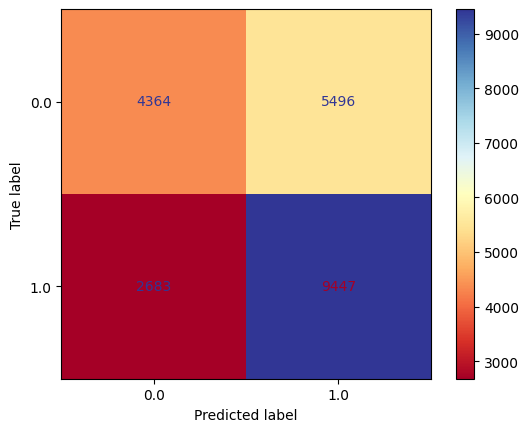

# 1.4 - Calculamos las métricas de evaluación del modelo

In [ ]:
# Extraigo los valores de la matriz de confusión
# Tengamos en cuenta que la variable 'mc_NB' contiene una 'tabla' con la siguiente forma: 0[VN,FP]
#                                                                                         1[FN,VP]
#                                                                                           0  1
VN_NB = mc_NB [0,0]
FP_NB = mc_NB [0,1]
FN_NB = mc_NB [1,0]
VP_NB = mc_NB [1,1]
# Una vez definidas estas variables, podemos proceder a calcular las métricas de evaluación del modelo

exactitudNB = (VP_NB + VN_NB) / mc_NB.sum() # 'cm.sum' es la manera de hacer la sumatoria de la tabla que contiene la variable 'mc'
errorNB = (FP_NB + FN_NB) / mc_NB.sum()
sensibilidadNB = VP_NB / (VP_NB + FN_NB)
especificidadNB = VN_NB / (VN_NB + FP_NB)
precisiónNB = VP_NB / (VP_NB + FP_NB)
mezclaNB = (exactitudNB + especificidadNB)/2

print(f'La exactitud del modelo es de: {exactitudNB:.2%}')
print(f'El error del modelo es de: {errorNB:.2%}')
print(f'La sensibilidad del modelo es de: {sensibilidadNB:.2%}')
print(f'La especificidad del modelo es de: {especificidadNB:.2%}')
print(f'La precisión del modelo es de: {precisiónNB:.2%}')
print(f'La mezcla entre exactitud y sensibilidad del modelo es de: {mezclaNB:.2%}')

La exactitud del modelo es de: 62.81%
El error del modelo es de: 37.19%
La sensibilidad del modelo es de: 77.88%
La especificidad del modelo es de: 44.26%
La precisión del modelo es de: 63.22%
La mezcla entre exactitud y sensibilidad del modelo es de: 53.53%


# 1.5 - Definimos industria con salarios más altos, e industria con edades más bajas

In [ ]:
# Filtramos las variables
XDGener = XD2[['Age', 'Female', 'Years', 'Certficates', 'Feedback', 'Salary']]
XDArray2 = np.array(XDGener)

In [ ]:
# Creamos una segunda variable que almacena el modelo para hacer la prediccion para la segunda hoja:
modeloNB2 = GaussianNB()
modeloNB2.fit(XDArray, ydArray)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GaussianNB()

In [ ]:
# Hacemos la predicción de la variable dependiente 'yd' en base a los 'XD' contenidos en la segunda hoja
ydPredNB2 = modeloNB2.predict(XDArray2)
ydPredNB2

array([1., 1., 0., 0., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       0., 1., 1., 1., 1., 1., 0., 0., 1., 1., 0., 0., 1., 0., 0., 1., 1.,
       1., 1., 0., 0., 0., 1., 1., 1., 0., 1., 1., 0., 1., 0., 1., 1., 1.,
       0., 1., 0., 1., 1., 0., 0., 1., 1., 0., 1., 0., 0., 1., 1., 1., 0.,
       1., 1., 1., 1., 1., 1., 0., 1., 0., 0., 1., 1., 1., 0., 1., 1., 1.,
       0., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 0., 0., 1., 1.])

In [ ]:
# Convertimos la predicción numérica de 'ydPredNB2' a texto:
BusinessNB2 = pd.Series(ydPredNB2).map({0: 'Hardware', 1: 'Software'})
BusinessNB2

,0
0,Software
1,Software
2,Hardware
3,Hardware
4,Software
...,...
95,Software
96,Hardware
97,Hardware
98,Software


In [ ]:
# Creamos una base de la segunda hoja con la industria predicha:
TechSalesRepsNB = XDGener.copy(deep = True)
TechSalesRepsNB ['Business'] = BusinessNB2
TechSalesRepsNB.head()

,Age,Female,Years,Certficates,Feedback,Salary,Business
0,50,0,1,1,3.52,43000,Software
1,52,1,2,5,3.91,95600,Software
2,54,1,9,3,2.04,78200,Hardware
3,62,1,1,1,1.54,52600,Hardware
4,43,1,2,2,1.67,67400,Software


In [ ]:
# Creamos una base comparable de la primera hoja, tomaremos de la primera hoja las variables independientes y la copiamos para no alterar de ninguna manera el dataset inicial:
ComparableTechSalesReps = TechSalesReps [['Age', 'Female', 'Years', 'Certficates', 'Feedback', 'Salary', 'Business']].copy(deep=True)
ComparableTechSalesReps.head()

,Age,Female,Years,Certficates,Feedback,Salary,Business
0,59,1,2,1,2.01,70200,0
1,52,0,10,4,3.64,133000,0
2,47,1,1,1,3.88,52600,1
3,61,0,2,3,2.70,96000,0
4,39,0,1,5,3.44,122000,1


In [ ]:
# Creamos una tabla completa comparable de la primera hoja:
DbCompletoNB = pd.concat([ComparableTechSalesReps, TechSalesRepsNB],ignore_index= True )
DbCompletoNB
# Ahora podemos ver como se agregan los 100 asesores de venta de la segunda hoja y ahora tenemos todos completos.

,Age,Female,Years,Certficates,Feedback,Salary,Business
0,59,1,2,1,2.01,70200,0
1,52,0,10,4,3.64,133000,0
2,47,1,1,1,3.88,52600,1
3,61,0,2,3,2.70,96000,0
4,39,0,1,5,3.44,122000,1
...,...,...,...,...,...,...,...
22085,22,0,5,2,3.43,43000,Software
22086,38,1,9,1,3.02,46400,Hardware
22087,56,0,2,5,3.88,99000,Hardware
22088,45,0,1,2,3.78,89000,Software


### Industria con salarios más altos

In [ ]:
fila_salario_max = DbCompletoNB.loc[DbCompletoNB['Salary'].idxmax()]
print(f"La industria con el salario individual más alto es: {fila_salario_max['Business']}")
print(f"Salario máximo: {fila_salario_max['Salary']:,.2f}")

La industria con el salario individual más alto es: 0
Salario máximo: 197,000.00


### Industria con edad más baja

In [ ]:
fila_edad_min = DbCompletoNB.loc[DbCompletoNB['Age'].idxmin()]
print(f"La industria con la edad individual más baja es: {fila_edad_min['Business']}")
print(f"Edad mínima: {fila_edad_min['Age']}")

La industria con la edad individual más baja es: 1
Edad mínima: 21


# 2 - Implementamos el modelo de Árboles de Decisión

# 2.2 - Almacenamos el modelo, lo entrenamos y predecimos con las variables independientes y dependientes (XD, yd)

In [ ]:
ModArbDec = DecisionTreeClassifier(criterion='gini', max_depth=4)
ModArbDec.fit (XD, yd)

DecisionTreeClassifier(max_depth=4)

In [ ]:
ydPredModArbDec = ModArbDec.predict(XD)
ydPredModArbDec

array([0, 1, 1, ..., 1, 1, 1])

# 2.3 - Implementamos la matriz de confusión

In [ ]:
mc_ModArbDec = confusion_matrix(yd, ydPredModArbDec)
mc_ModArbDec

array([[ 2698,  7162],
       [   63, 12067]])

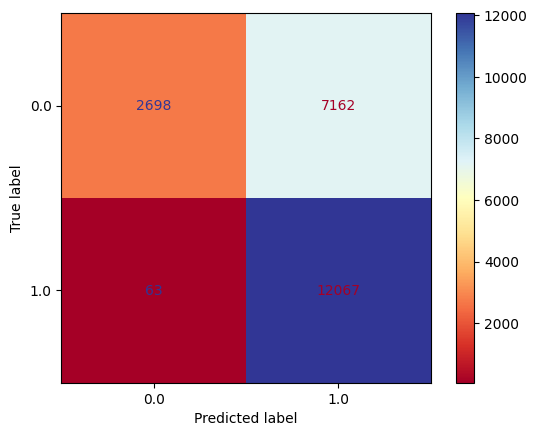

In [ ]:
dispModArbDec = ConfusionMatrixDisplay(mc_ModArbDec, display_labels=modeloNB.classes_)
dispModArbDec.plot(cmap = 'RdYlBu')
plt.show()

# 2.4 Calculamos las métricas de evaluación del modelo

In [ ]:
# Extraigo los valores de la matriz de confusión
# Tengamos en cuenta que la variable 'mc_ModArbDec' contiene una 'tabla' con la siguiente forma: 0[0,1]
#                                                                                      1[0,1]
#
VN_ModArbDec = mc_ModArbDec [0,0]
FP_ModArbDec = mc_ModArbDec [0,1]
FN_ModArbDec = mc_ModArbDec [1,0]
VP_ModArbDec = mc_ModArbDec [1,1]
# Una vez definidas estas variables, podemos proceder a calcular las métricas de evaluación del modelo

exactitudModArbDec = (VP_ModArbDec + VN_ModArbDec) / mc_ModArbDec.sum() # 'cm.sum' es la manera de hacer la sumatoria de la tabla que contiene la variable 'mc'
errorModArbDec = (FP_ModArbDec + FN_ModArbDec) / mc_ModArbDec.sum()
sensibilidadModArbDec = VP_ModArbDec / (VP_ModArbDec + FN_ModArbDec)
especificidadModArbDec = VN_ModArbDec / (VN_ModArbDec + FP_ModArbDec)
precisiónModArbDec = VP_ModArbDec / (VP_ModArbDec + FP_ModArbDec)
mezclaModArbDec = (exactitudModArbDec + especificidadModArbDec)/2

print(f'La exactitud del modelo es de: {exactitudModArbDec:.2%}')
print(f'El error del modelo es de: {errorModArbDec:.2%}')
print(f'La sensibilidad del modelo es de: {sensibilidadModArbDec:.2%}')
print(f'La especificidad del modelo es de: {especificidadModArbDec:.2%}')
print(f'La precisión del modelo es de: {precisiónModArbDec:.2%}')
print(f'La mezcla entre exactitud y sensibilidad del modelo es de: {mezclaModArbDec:.2%}')

La exactitud del modelo es de: 67.14%
El error del modelo es de: 32.86%
La sensibilidad del modelo es de: 99.48%
La especificidad del modelo es de: 27.36%
La precisión del modelo es de: 62.75%
La mezcla entre exactitud y sensibilidad del modelo es de: 47.25%


# 2.5 - Graficamos el modelo

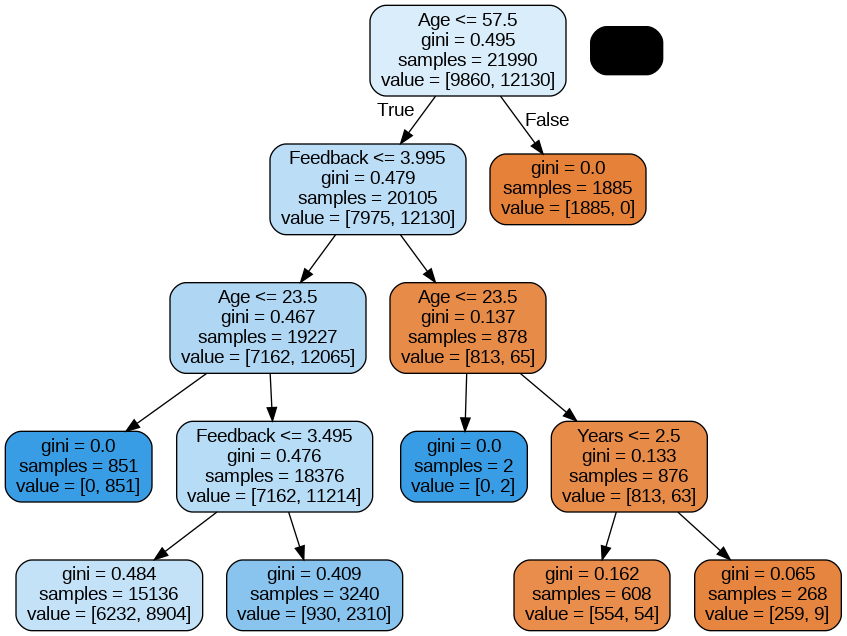

In [ ]:
var = ['Age', 'Female', 'Years', 'Certficates', 'Feedback', 'Salary']
dot_data = StringIO()
export_graphviz (ModArbDec, out_file=dot_data, feature_names=var, filled=True, rounded=True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())


In [ ]:
ModArbDec.classes_

array([0, 1])

# 3 - Implementamos el modelo KNN (K Nearest Neighbors)

# 3.2 -  Almacenamos el modelo, lo entrenamos y predecimos con las variables independientes y dependientes (XD, yd)

In [ ]:
KNNmodel = KNeighborsClassifier(n_neighbors=10)
KNNmodel.fit(XD, yd)

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier(n_neighbors=10)

In [ ]:
ydPredKNNModel= KNNmodel.predict(XD)
ydPredKNNModel

array([0, 0, 1, ..., 0, 0, 1])

# 3.3 - Implementamos la matriz de confusión y de correlación

### Matriz de confusión

In [ ]:
mc_KNNModel = confusion_matrix (yd, ydPredKNNModel)
mc_KNNModel

array([[6330, 3530],
       [3223, 8907]])

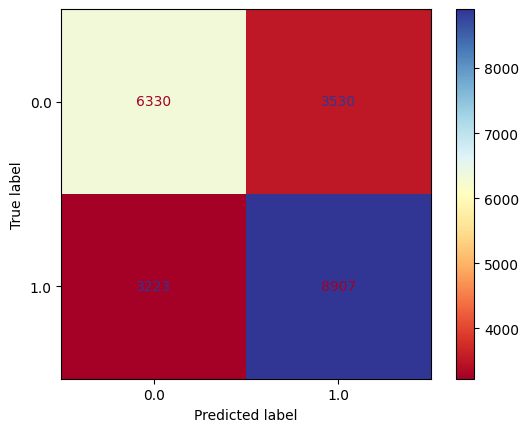

In [ ]:
dispKNNModel = ConfusionMatrixDisplay(mc_KNNModel, display_labels=modeloNB.classes_)
dispKNNModel.plot(cmap = 'RdYlBu')
plt.show()

### Matriz de correlación

In [ ]:
dfinf = pd.DataFrame (np.column_stack((XD, yd)))
dfinf.columns = [['Age', 'Female', 'Years', 'Certficates', 'Feedback', 'Salary', 'Business']]
mCorrelacion = dfinf.corr()
mCorrelacion

,Age,Female,Years,Certficates,Feedback,Salary,Business
Age,1.000000,-0.018215,0.057280,-0.022949,0.000305,0.263914,-0.242106
Female,-0.018215,1.000000,-0.007821,0.002982,0.012601,-0.162976,0.082904
Years,0.057280,-0.007821,1.000000,-0.008271,0.001754,0.093080,-0.101416
Certficates,-0.022949,0.002982,-0.008271,1.000000,-0.004496,0.458440,0.094987
Feedback,0.000305,0.012601,0.001754,-0.004496,1.000000,0.312452,-0.014701
Salary,0.263914,-0.162976,0.093080,0.458440,0.312452,1.000000,-0.072924
Business,-0.242106,0.082904,-0.101416,0.094987,-0.014701,-0.072924,1.000000


<Axes: xlabel='None', ylabel='None'>

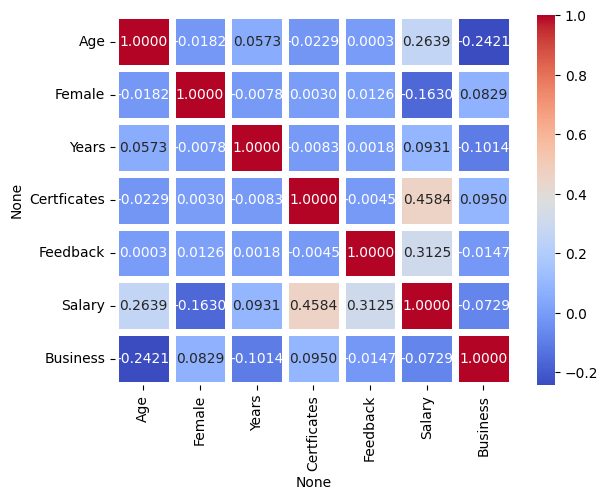

In [ ]:
sns.heatmap(mCorrelacion, cmap = 'coolwarm',linewidth = 5, annot = True, fmt = '.4f' )
# En este caso, las 2 variables con mayor correlación serían 'Salary vs Certficates'

# 3.4 - Calculamos las métricas de evaluación del modelo

In [ ]:
# Extraigo los valores de la matriz de confusión:
# Tengamos en cuenta que la variable 'mc_KNNModel' contiene una 'tabla' con la siguiente forma: 0[0,1]
#                                                                                      1[0,1]

VN_KNNModel = mc_KNNModel [0,0]
FP_KNNModel = mc_KNNModel [0,1]
FN_KNNModel = mc_KNNModel [1,0]
VP_KNNModel = mc_KNNModel [1,1]

# Una vez definidas estas variables, podemos proceder a calcular las métricas de evaluación del modelo.

exactitudKNNModel = (VP_KNNModel + VN_KNNModel) / mc_KNNModel.sum() # 'cm.sum' es la manera de hacer la sumatoria de la tabla que contiene la variable 'mc'.
errorKNNModel = (FP_KNNModel + FN_KNNModel) / mc_KNNModel.sum()
sensibilidadKNNModel = VP_KNNModel / (VP_KNNModel + FN_KNNModel)
especificidadKNNModel = VN_KNNModel / (VN_KNNModel + FP_KNNModel)
precisiónKNNModel = VP_KNNModel / (VP_KNNModel + FP_KNNModel)
mezclaKNNModel = (exactitudKNNModel + especificidadKNNModel)/2

print(f'La exactitud del modelo es de: {exactitudKNNModel:.2%}')
print(f'El error del modelo es de: {errorKNNModel:.2%}')
print(f'La sensibilidad del modelo es de: {sensibilidadKNNModel:.2%}')
print(f'La especificidad del modelo es de: {especificidadKNNModel:.2%}')
print(f'La precisión del modelo es de: {precisiónKNNModel:.2%}')
print(f'La mezcla entre exactitud y sensibilidad del modelo es de: {mezclaKNNModel:.2%}')

La exactitud del modelo es de: 69.29%
El error del modelo es de: 30.71%
La sensibilidad del modelo es de: 73.43%
La especificidad del modelo es de: 64.20%
La precisión del modelo es de: 71.62%
La mezcla entre exactitud y sensibilidad del modelo es de: 66.74%


# 3.5 - Comparamos las 3 mezclas de exactitud y sensibilidad de cada módelo


In [ ]:
print(f'La mezcla entre exactitud y sensibilidad del modelo Naive Bayes es de: {mezclaNB:.2%}')
print(f'La mezcla entre exactitud y sensibilidad del modelo de Árboles de Decisión es de: {mezclaModArbDec:.2%}')
print(f'La mezcla entre exactitud y sensibilidad del modelo K Nearest Neighbors es de: {mezclaKNNModel:.2%}')

La mezcla entre exactitud y sensibilidad del modelo Naive Bayes es de: 53.53%
La mezcla entre exactitud y sensibilidad del modelo de Árboles de Decisión es de: 47.25%
La mezcla entre exactitud y sensibilidad del modelo K Nearest Neighbors es de: 66.74%


# 3.6 - Graficamos un diagrama de disperción con las variables con mayor correlación

(Text(0.5, 0, 'Salary'), Text(0, 0.5, 'Certficates'))

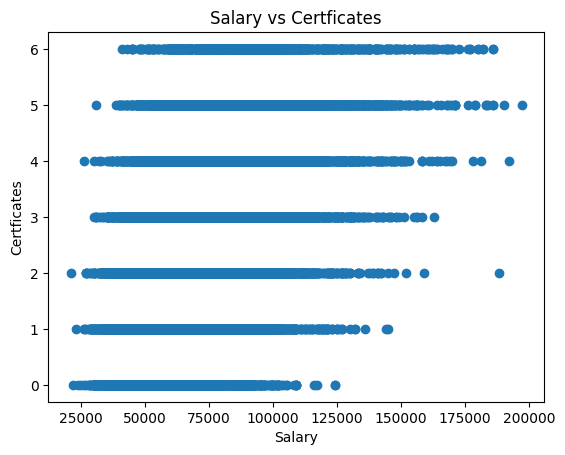

In [ ]:
scatter = plt.scatter(XD['Salary'], XD['Certficates'])
# Este es el scatter de los XD (gráfico de dispersión de las variables independientes)
plt.title('Salary vs Certficates')
plt.xlabel('Salary'), plt.ylabel('Certficates')
# Podemos observar claramente que: A mayor cantidad de certificados obtenidos, también es mayor el salario recibido.

# 4 - Predecimos la variable dependiente (yd) ahora con unos nuevos datos (XD2) tomados de Techsales_Rep_2

# 4.2 - Definimos el módelo a utilizar para realizar el pronóstico una vez entrenado con las nuevas variables

In [ ]:
# Dado que vimos que KNN es el módelo que tiene una mezcla con mejor comportamiento frente al pronóstico de la industria a la que pertenece un asesor de ventas, haremos el pronóstico para estos 100 casos con KNN.
KNNmodel2 = KNeighborsClassifier(n_neighbors=10)
KNNmodel2

KNeighborsClassifier(n_neighbors=10)

In [ ]:
# Entrenamos con los nuevos datos y predecimos
KNNmodel2.fit(XD,yd)
ydPredKNNmodel2= KNNmodel2.predict(XD2)
ydPredKNNmodel2

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


array([1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1])

# 4.3 - Contamos cuántas personas pronósticadas pertenecen a la industria de 'Hardware' o 'Software'

In [ ]:
counts0 = (ydPredKNNmodel2 == 0).sum()
counts1 = (ydPredKNNmodel2 == 1).sum()
print(f'La cantidad de personas pronósticadas como "Hardware" es de {counts0} personas')
print(f'La cantidad de personas pronósticadas como "Software" es de {counts1} personas')

La cantidad de personas pronósticadas como "Hardware" es de 36 personas
La cantidad de personas pronósticadas como "Software" es de 64 personas


# 5 - Implementamos el modelo K Means para clusterizar

# Almacenamos el modelo y lo entrenamos con las variables independientes (XD)

In [ ]:
np.random.seed(42)
k = 5
KMeansModel = KMeans(n_clusters = k, init = 'random', random_state=42)
KMeansModel.fit(XD)

KMeans(init='random', n_clusters=5, random_state=42)

### Asignamos y almacenamos dentro de variables, las etiquetas y centroides

In [ ]:
# Obtengo del modelo los clústeres y los centroides:
labels = KMeansModel.labels_
centroids = KMeansModel.cluster_centers_
labels, centroids
# Un clúster es una nube de puntos. Un centroide es como un promedio de esos puntos, es decir, un punto imaginario que es el promedio de esos puntos del clúster. Nos permite saber qué tan lejos están los puntos del centroide.

(array([0, 3, 1, ..., 1, 0, 1], dtype=int32),
 array([[4.12080236e+01, 4.37649039e-01, 2.60246879e+00, 2.39037733e+00,
         2.55907701e+00, 6.58741198e+04],
        [3.70520666e+01, 4.48201825e-01, 2.36410807e+00, 1.69994632e+00,
         2.37341206e+00, 4.85997495e+04],
        [4.50840752e+01, 2.55852291e-01, 2.86811738e+00, 3.62017804e+00,
         3.02814375e+00, 1.03464359e+05],
        [4.71178414e+01, 1.60792952e-01, 3.27973568e+00, 4.37444934e+00,
         3.32484581e+00, 1.34942291e+05],
        [4.35409867e+01, 3.51903958e-01, 2.76702307e+00, 2.99155881e+00,
         2.79139373e+00, 8.30070906e+04]]))

# 5.2 - Creamos dos personalidades ficticias 'XDi' y las graficamos

### Primera personalidad XDi

In [ ]:
# Creamos la personalidad ficticia 'XDi'
XDi1 = [26,1,5,5,3,55000] # En el mismo orden en el que ordenamos las columnas anteriormente
# Convertimos los datos a un dataframe y les asigno a las columnas los nombres de las columnas de la variable 'XD'
XDiDF1 = pd.DataFrame([XDi1], columns = XD.columns) # En los dataframes los datos deben ser puestos como 'series'. Es por eso que ponemos 'XD' dentro de [].
# Para calcular la probabilidad usaremos el modelo KNN, así de este modo, usamos el modelo que tiene mejor comportamiento para clasificar.
ydi1 = KNNmodel.predict(XDiDF1)
ydi1

array([0])

### Segunda personalidad XDi

In [ ]:
XDi2 = [33,0,3,3,3,77000]
XDiDF2 = pd.DataFrame([XDi2], columns = XD.columns)
ydi2 = KNNmodel.predict(XDiDF2)
ydi2

array([0])

### Graficamos ambas personalidades

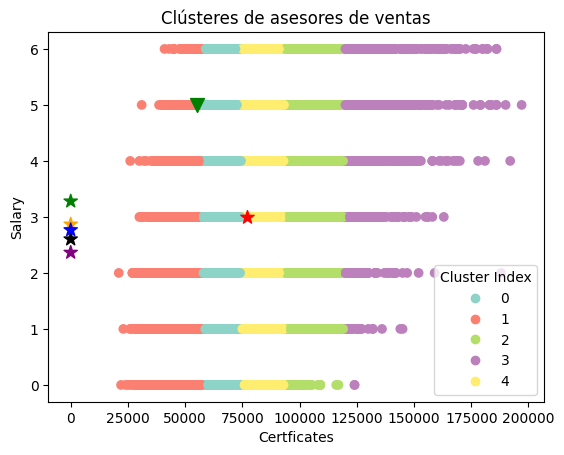

In [ ]:
# Primera personalidad = Triángulo verde invertido
# Segunda personalidad = Estrella roja
scatter = plt.scatter(XD['Salary'], XD['Certficates'], c = labels, cmap= 'Set3')
colors = ['black', 'purple', 'orange', 'green', 'blue']
plt.scatter(centroids[:,1], centroids[:,2], facecolor = colors, marker = '*', s = 100)
plt.scatter(XDiDF1 ['Salary'], XDiDF1 ['Certficates'], facecolor = 'green', s = 100, marker = 'v')
plt.scatter(XDiDF2 ['Salary'], XDiDF2 ['Certficates'], facecolor = 'red', s = 100, marker = '*')
plt.xlabel('Certficates'), plt.ylabel('Salary') # Agregamos etiquetas a las variables del eje X y Y.
plt.legend(title = 'Cluster Index', *scatter.legend_elements()) # Extraemos los clústeres contenidos en el scatter.
plt.title('Clústeres de asesores de ventas') # Agregamos un titulo que explique la gráfica.
plt.show()

In [ ]:
# Predecimos el clúster de solicitantes de prueba
KMeansModel.predict(XDiDF1)
# Como shell obtenemos un array que indica que nuestro solicitante ficticio se ubicaría en el segundo cluster (0,1). Concordante con el triángulo verde invertido que encontramos en la gráfica previamente hecha.

array([1], dtype=int32)

In [ ]:
KMeansModel.predict(XDiDF2)

array([4], dtype=int32)

# 5.3 - Generamos los informes de los clústeres

In [ ]:
# Necesito completar el dataframe original colocándole una nueva columna con los clústeres para cada asesor.
AAA = XD.copy(deep=True)
AAA.loc [:, 'Business'] = yd
AAA.loc [:, 'cluster'] = labels
AAA

,Age,Female,Years,Certficates,Feedback,Salary,Business,cluster
0,59,1,2,1,2.01,70200,0,0
1,52,0,10,4,3.64,133000,0,3
2,47,1,1,1,3.88,52600,1,1
3,61,0,2,3,2.70,96000,0,2
4,39,0,1,5,3.44,122000,1,3
...,...,...,...,...,...,...,...,...
21985,44,0,1,4,1.80,128000,1,3
21986,23,1,6,6,1.77,53400,1,1
21987,48,1,4,0,2.46,50400,0,1
21988,29,0,4,2,3.68,70000,1,0


In [ ]:
# Contamos cuántos de cada industria hay por cada clúster:
counts_0 = AAA.groupby('cluster').agg({"Business": lambda x: (x==0).sum()}) # Cuenta de Hardware (0).
counts_1 = AAA.groupby('cluster').agg({"Business": lambda x: (x==1).sum()}) # Cuenta de Software (1).
df = pd.DataFrame (np.column_stack ((counts_0, counts_1)))
df.columns = ['Hardware', 'Software']
df['Total'] = df.sum(axis=1)
df['ProbHardware'] = (df ['Hardware']/df['Total']).map('{:,.2%}'.format)
df['ProbSoftware'] = (df ['Software']/df['Total']).map('{:,.2%}'.format)
df

,Hardware,Software,Total,ProbHardware,ProbSoftware
0,3194,3935,7129,44.80%,55.20%
1,2181,3408,5589,39.02%,60.98%
2,1458,1575,3033,48.07%,51.93%
3,464,444,908,51.10%,48.90%
4,2563,2768,5331,48.08%,51.92%


# 5.4 - Graficamos en 3D

In [ ]:
# Agregamos una tercera variable para graficar el eje Z, en este caso vemos en la matriz de correlación que la siguiente variable con mayor coeficiente es 'feedback'
fig = px.scatter_3d(AAA.astype({'cluster':str}), 'Certficates', 'Salary', 'Feedback', color = 'cluster')
fig = go.Figure(fig)
# Ploteo
fig.show()
# Vemos como podemos graficar en 3 dimensiones el gráfico e incluso podemos interactuar y ver detalles de los 'clústers'.

# Graficamos entonces, las nuevas personalidades ficticias y vemos dónde se ubican:
fig.add_trace(go.Scatter3d(x=[XDi1[1]], y=[XDi1[2]], z=[XDi1[3]], name='Personalidad 1', marker = dict(color='red')))
fig.add_trace(go.Scatter3d(x=[XDi2[1]], y=[XDi2[2]], z=[XDi2[3]], name='Personalidad 2', marker = dict(color='purple')))
# Grafico los centroides:
fig.add_trace(go.Scatter3d(x = centroids [:,1].tolist(), y =  centroids [:,2].tolist(), z = centroids [:,3].tolist(), name = 'Centroides', marker = dict (color='black'), mode='markers'))

#**Solición cuestionario**

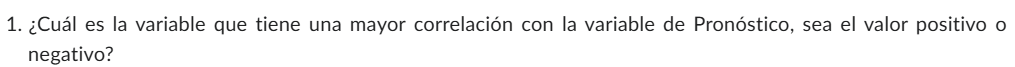

La variable con mayor correlación con la variable de pronóstico (Business), haciendo uso de la matriz de correlación (Ver índice 3.3 - Matriz de correlación) serían:

***Business vs Age***


image.png

Las variables que se encuentran mayormente relacionadas (Ver índice 3.3 - Matriz de correlación) serían:

***Certficates vs Salary***

Con un *coeficiente de 0.45*, lo cual indicaría una correlación moderada que podría permitirnos pensar que a mayor cantidad de certificados, la tendencia muestra también un mayor salario

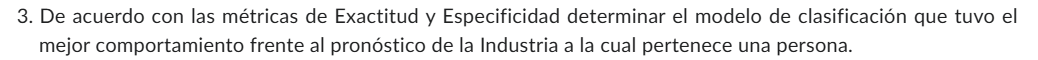


 Al comparar el promedio entre exactitud y sensibilidad de los 3 modelos utilizados (ver índice 3.5), obtenemos los siguientes resultados:
- Naive Bayes: Promedio de 53.53%
- Árboles de Decisión: Promedio de 47.25%
- K Nearest Neighbors (KNN): Promedio de 66.74%

Vemos entonces, que ***el modelo KNN*** es el que tiene un mejor comportamiento frente al pronóstico de la industria a la cual pertenece uno de los asesores del dataset trabajado.

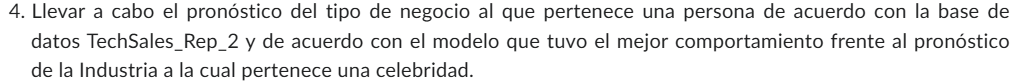

(Ver índice 4.2)

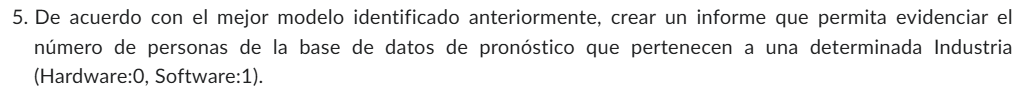

(Ver índice 4.3)

La cantidad de personas pronósticadas como "Hardware" es de 36 personas

La cantidad de personas pronósticadas como "Software" es de 64 personas

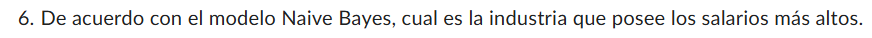

(Ver índice 1.5 - 'Industria con salario más alto')

La industria con el salario promedio más alto es: 0 (Hardware)

Salario más alto en la industria: 197,000.00

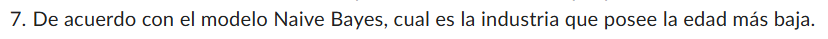

(Ver índice 1.5 - 'Industria con edad más baja')

La industria con la edad individual más baja es: 1 (Software)

Edad mínima: 21

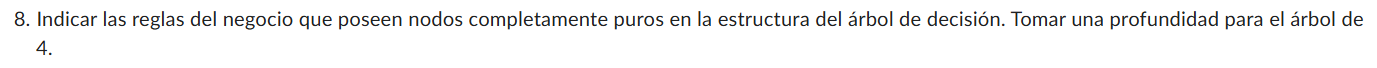

El modelo de Árboles de Decisión (Ver índice 2.5) nos muestra que hay 3 nodos puros, con coeficiente gini de = 0.0

Sus reglas son:
- IF 'Age' >= 57.5
- IF 'Age' <= 57.5 AND 'Feedback' >= 3.995 AND 'Age' <= 23.5
- IF 'Age' <= 57.5 AND 'Feedback' <= 3.995 AND 'Age' <= 23.5


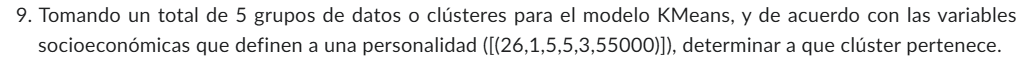

Según la gráfica y el método '.predict' (Ver índice 5.2 -Primera personalidad XDi ), nos indican que la personalidad ficticia se úbica en el clúster 2

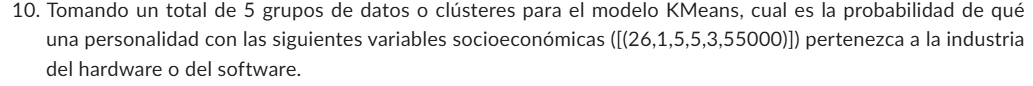

(Ver índice 5.3)

Según los informes de los clústeres, viendo que la personalidad pertenece al **segundo clúster**, las probabilidades de pertenecer a la industria del 'Hardware' son del 39.02%, mientras que las probabilidades de pertenecer a la industria del 'Software' son del  60.98%.

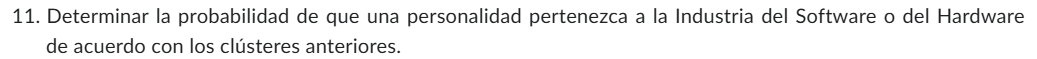

(Ver índice 5.3)

Según los informes de los clústeres, viendo que la personalidad pertenece al **quinto clúster**, las probabilidades de pertenecer a la industria del 'Hardware' son del 48.08%, mientras que las probabilidades de pertenecer a la industria del 'Software' son del  51.92%.

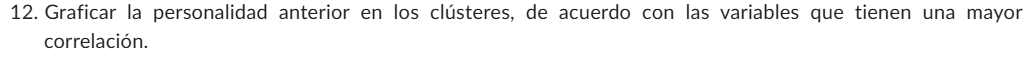

(Ver índice 5.2 - Graficamos ambas personalidades) y (Ver índice 5.3)